# Waypoint Constraints

This example constrains Amsterdam Schiphol (`EHAM`) to Rome Fiumicino (`LIRF`) through named fixes from OpenAP's packaged navigation database. The fixes intentionally create a one-sided convex detour away from the direct route, and the optimizer is constrained to pass within 2 km of each fix.


In [1]:
import warnings

import matplotlib.pyplot as plt
import openap
from cartopy import crs as ccrs
from cartopy.feature import BORDERS, LAND, OCEAN

import numpy as np
import opentop as top

warnings.filterwarnings("ignore")
from opentop.plotting import (  # noqa: E402
    NEUTRAL_COLOR,
    OKABE_ITO,
    apply_publication_style,
)

apply_publication_style()

In [2]:
actype = "A320"
origin = "EHAM"
destination = "LIRF"
m0 = 0.85
fix_names = ("SIGEN", "FUSSE", "ROKIB")
waypoint_tolerance_m = 2_000

waypoints = []
for fix_name in fix_names:
    lat, lon, _ = openap.nav.fix(fix_name)
    waypoints.append((float(lat), float(lon)))

list(zip(fix_names, waypoints))

[('SIGEN', (50.846111, 8.279444)),
 ('FUSSE', (47.574289, 10.429847)),
 ('ROKIB', (45.935556, 11.692222))]

In [3]:
cruise_optimizer = top.Cruise(actype, origin, destination, m0)
cruise_optimizer.setup()
cruise_flight = cruise_optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=waypoint_tolerance_m,
)

complete_optimizer = top.CompleteFlight(actype, origin, destination, m0)
complete_optimizer.setup()
complete_flight = complete_optimizer.trajectory(
    objective="fuel",
    waypoints=waypoints,
    waypoint_tolerance_m=waypoint_tolerance_m,
)

In [4]:
def closest_distances(flight, waypoints):
    distances = []
    for waypoint in waypoints:
        fix_distances = [
            openap.aero.distance(lat, lon, waypoint[0], waypoint[1])
            for lat, lon in zip(flight.latitude, flight.longitude)
        ]
        distances.append(min(fix_distances))
    return distances


print("Route: " + origin + " -> " + " -> ".join(fix_names) + " -> " + destination)
for label, optimizer, flight in (
    ("Cruise", cruise_optimizer, cruise_flight),
    ("CompleteFlight", complete_optimizer, complete_flight),
):
    fuel_burn = flight.mass.iloc[0] - flight.mass.iloc[-1]
    elapsed_time = flight.ts.iloc[-1] / 60
    print(f"\n{label}")
    print(f"  success: {optimizer.success}")
    print(f"  fuel burn: {fuel_burn:.1f} kg")
    print(f"  elapsed time: {elapsed_time:.1f} min")
    for fix_name, distance in zip(fix_names, closest_distances(flight, waypoints)):
        print(f"  {fix_name}: closest trajectory point {distance / 1000:.1f} km")

Route: EHAM -> SIGEN -> FUSSE -> ROKIB -> LIRF

Cruise
  success: True
  fuel burn: 4382.8 kg
  elapsed time: 97.2 min
  SIGEN: closest trajectory point 2.0 km
  FUSSE: closest trajectory point 2.0 km
  ROKIB: closest trajectory point 2.0 km

CompleteFlight
  success: True
  fuel burn: 4811.7 kg
  elapsed time: 108.4 min
  SIGEN: closest trajectory point 2.0 km
  FUSSE: closest trajectory point 2.0 km
  ROKIB: closest trajectory point 2.0 km


In [5]:
origin_info = openap.nav.airport(origin)
destination_info = openap.nav.airport(destination)
airport_points = [
    (origin, float(origin_info["lat"]), float(origin_info["lon"])),
    (destination, float(destination_info["lat"]), float(destination_info["lon"])),
]

all_lons = [*cruise_flight.longitude, *complete_flight.longitude]
all_lats = [*cruise_flight.latitude, *complete_flight.latitude]
all_lons.extend(lon for _, lon in waypoints)
all_lats.extend(lat for lat, _ in waypoints)
all_lons.extend(lon for _, _, lon in airport_points)
all_lats.extend(lat for _, lat, _ in airport_points)
map_extent = [
    min(all_lons) - 1.0,
    max(all_lons) + 1.0,
    min(all_lats) - 0.8,
    max(all_lats) + 0.8,
]


def plot_flight_summary(flight, title, color):
    projection = ccrs.TransverseMercator(
        central_longitude=9,
        central_latitude=47,
    )
    fig = plt.figure(figsize=(14, 7))
    grid = fig.add_gridspec(2, 2, width_ratios=(1.4, 1))
    ax = fig.add_subplot(grid[:, 0], projection=projection)
    altitude_ax = fig.add_subplot(grid[0, 1])
    speed_ax = fig.add_subplot(grid[1, 1], sharex=altitude_ax)
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(LAND, facecolor="#f3f0e8", edgecolor="none")
    ax.add_feature(OCEAN, facecolor="#d9ecf2", edgecolor="none")
    ax.add_feature(BORDERS, lw=0.5, color="0.45")
    ax.coastlines(resolution="50m", lw=0.5, color="0.45")
    ax.gridlines(draw_labels=True, color="0.6", alpha=0.5, ls="--")

    ax.plot(
        [airport_points[0][2], airport_points[1][2]],
        [airport_points[0][1], airport_points[1][1]],
        color=NEUTRAL_COLOR,
        lw=1.0,
        ls="--",
        label="Direct airport line",
        transform=ccrs.PlateCarree(),
        zorder=1,
    )
    ax.plot(
        flight.longitude,
        flight.latitude,
        marker="o",
        color=color,
        lw=1.5,
        ms=4,
        label="Optimized trajectory",
        transform=ccrs.PlateCarree(),
        zorder=3,
    )
    ax.scatter(
        [lon for _, lon in waypoints],
        [lat for lat, _ in waypoints],
        marker="x",
        s=90,
        color=OKABE_ITO[1],
        label="Fixes",
        transform=ccrs.PlateCarree(),
        zorder=6,
    )
    ax.scatter(
        [lon for _, _, lon in airport_points],
        [lat for _, lat, _ in airport_points],
        marker="^",
        s=80,
        color=NEUTRAL_COLOR,
        label="Airports",
        transform=ccrs.PlateCarree(),
        zorder=7,
    )

    for fix_name, (lat, lon) in zip(fix_names, waypoints):
        ax.text(
            lon + 0.08,
            lat + 0.05,
            fix_name,
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=8,
        )
    for airport, lat, lon in airport_points:
        ax.text(
            lon + 0.08,
            lat + 0.05,
            airport,
            fontsize=9,
            transform=ccrs.PlateCarree(),
            zorder=8,
        )

    ax.set_title("Ground track")
    ax.legend(loc="lower left")

    time_min = flight.ts / 60
    altitude_ax.plot(time_min, flight.altitude, marker="o", ms=4, color=color)
    altitude_ax.set_ylabel("Altitude [ft]")
    altitude_ax.set_title("Altitude profile")
    altitude_ax.grid(True, alpha=0.3)

    speed_ax.plot(time_min, flight.tas, marker="o", ms=4, color=color)
    speed_ax.set_xlabel("Elapsed time [min]")
    speed_ax.set_ylabel("TAS [kt]")
    speed_ax.set_title("Speed profile")
    speed_ax.grid(True, alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

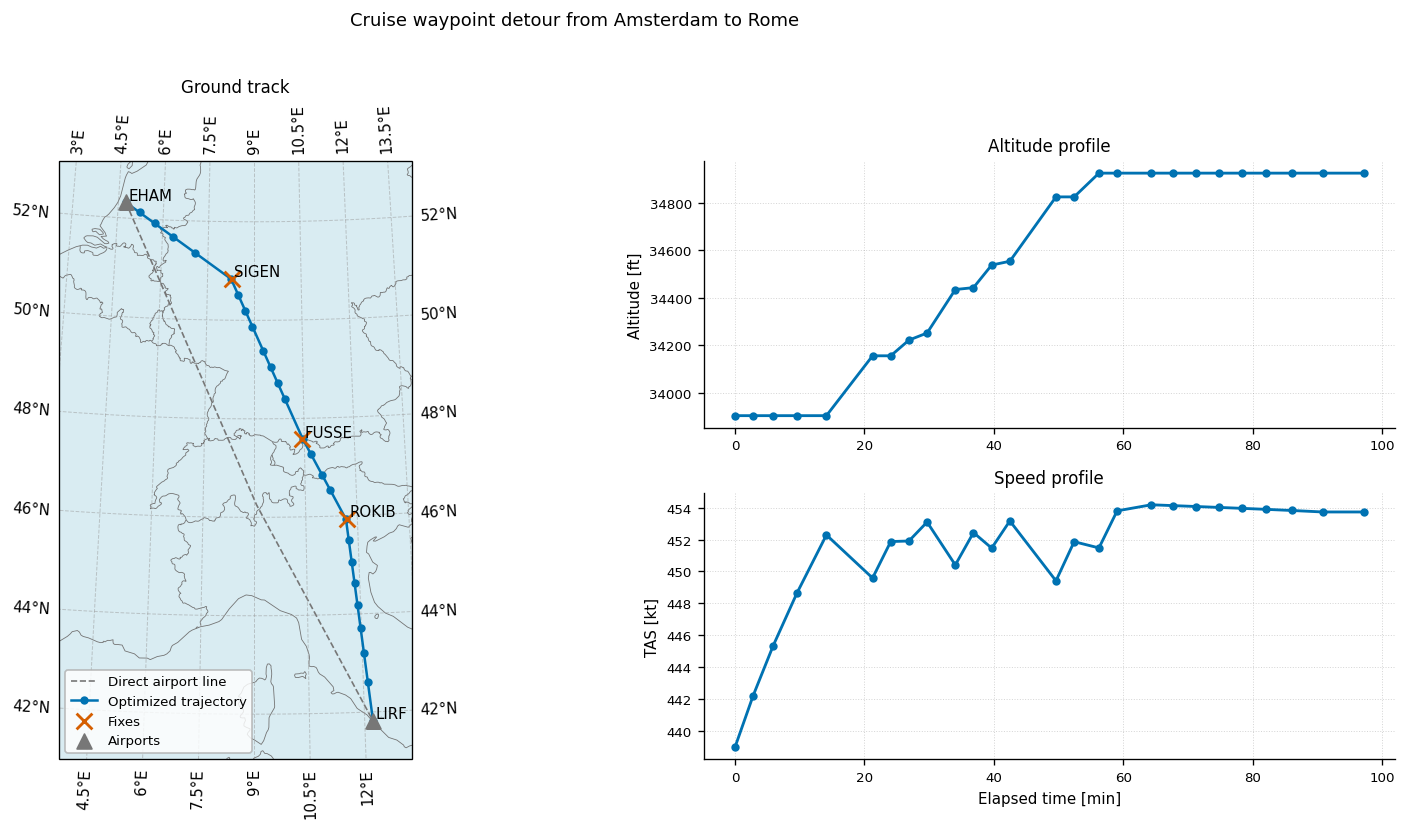

In [6]:
plot_flight_summary(
    cruise_flight,
    "Cruise waypoint detour from Amsterdam to Rome",
    OKABE_ITO[0],
)

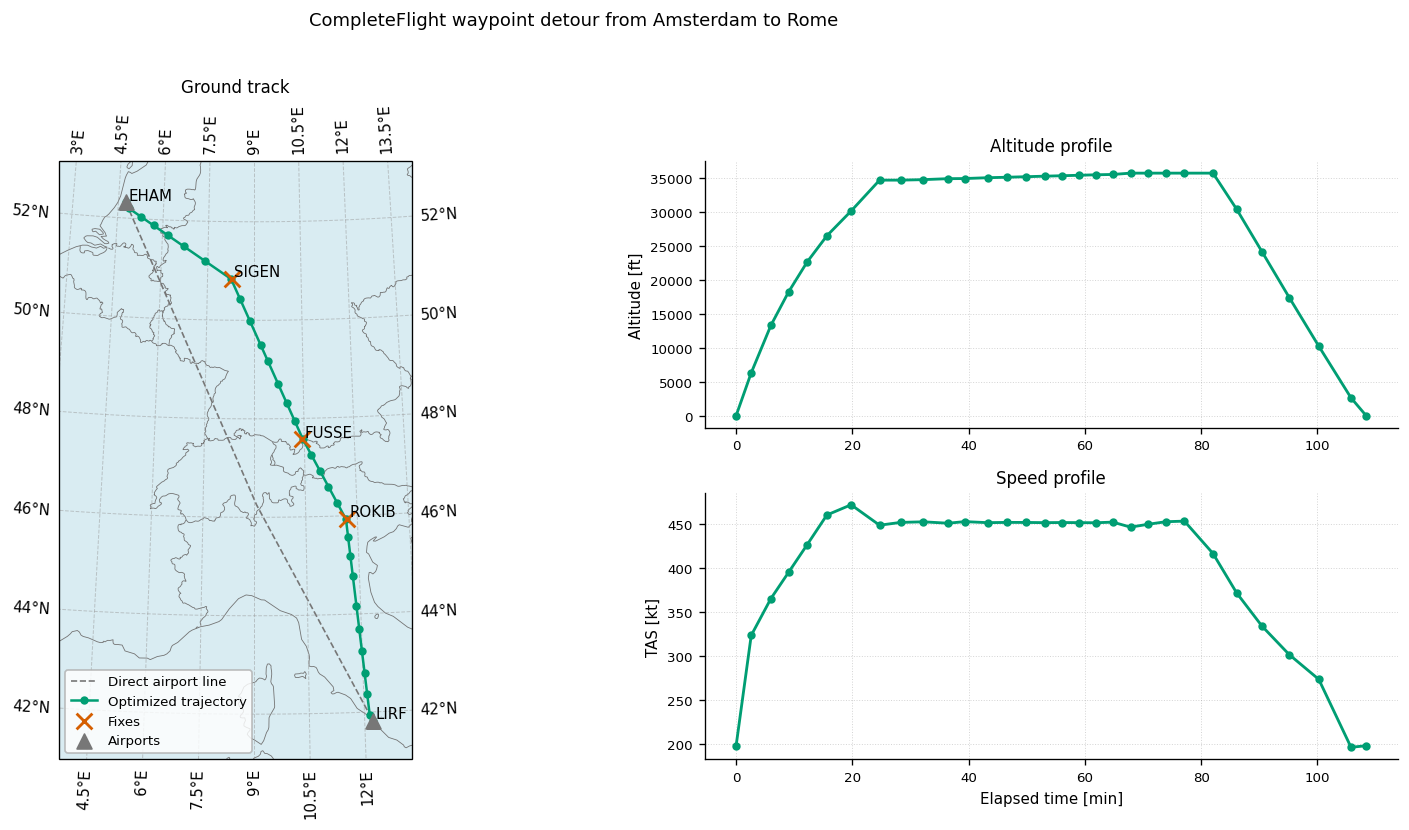

In [7]:
plot_flight_summary(
    complete_flight,
    "CompleteFlight waypoint detour from Amsterdam to Rome",
    OKABE_ITO[2],
)

In [8]:
# Altitude and speed profiles are included beside each ground-track plot.

## Time-normalized smoothness constraints

With optimized interval durations, adjacent-control changes are constrained as physical rates rather than fixed changes per node. Vertical acceleration is limited to 5 fpm/s and turn rate to 0.5 deg/s. This allows a larger change across a long interval without relaxing the rate limit on short intervals.

Cruise
  optimized dt range: 168.51 to 427.75 s
  max |vertical acceleration|: 0.1899 fpm/s
  max |turn rate|: 0.0699 deg/s
  max per-node changes: 39.0 fpm, 29.89 deg
CompleteFlight
  optimized dt range: 156.00 to 332.93 s
  max |vertical acceleration|: 4.4176 fpm/s
  max |turn rate|: 0.1733 deg/s
  max per-node changes: 1302.0 fpm, 31.27 deg


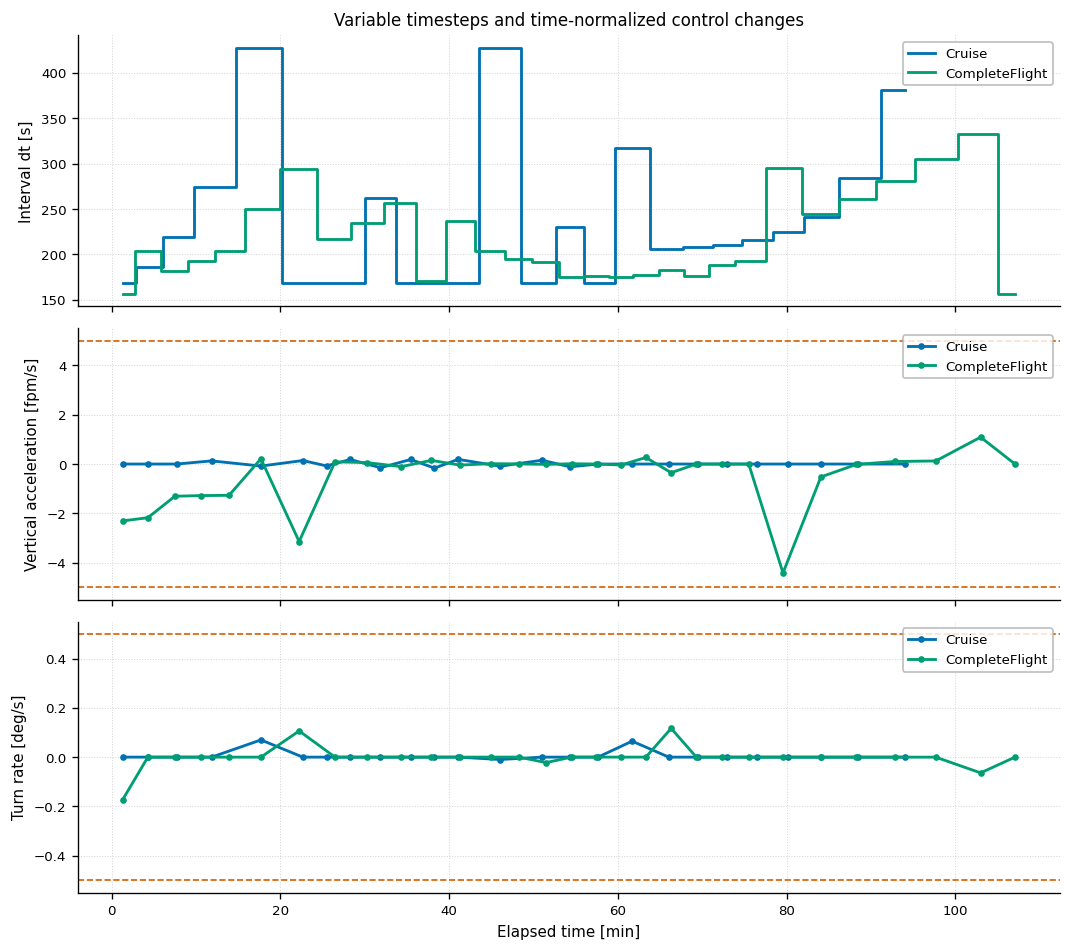

In [9]:
def control_rate_diagnostics(flight):
    timestamps = flight.ts.to_numpy()
    interval_dt = np.diff(timestamps)
    time_midpoint = (timestamps[:-1] + timestamps[1:]) / 120
    vertical_rate = flight.vertical_rate.to_numpy()
    heading = np.unwrap(np.deg2rad(flight.heading.to_numpy()))
    return {
        "time_midpoint": time_midpoint,
        "interval_dt": interval_dt,
        "vertical_acceleration": np.diff(vertical_rate) / interval_dt,
        "turn_rate": np.rad2deg(np.diff(heading)) / interval_dt,
        "vertical_rate_change": np.diff(vertical_rate),
        "heading_change": np.rad2deg(np.diff(heading)),
    }


fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for label, flight, color in (
    ("Cruise", cruise_flight, OKABE_ITO[0]),
    ("CompleteFlight", complete_flight, OKABE_ITO[2]),
):
    rates = control_rate_diagnostics(flight)
    print(label)
    print(
        f"  optimized dt range: {rates['interval_dt'].min():.2f} to "
        f"{rates['interval_dt'].max():.2f} s"
    )
    print(
        "  max |vertical acceleration|: "
        f"{np.abs(rates['vertical_acceleration']).max():.4f} fpm/s"
    )
    print(f"  max |turn rate|: {np.abs(rates['turn_rate']).max():.4f} deg/s")
    print(
        "  max per-node changes: "
        f"{np.abs(rates['vertical_rate_change']).max():.1f} fpm, "
        f"{np.abs(rates['heading_change']).max():.2f} deg"
    )

    axes[0].step(
        rates["time_midpoint"],
        rates["interval_dt"],
        where="mid",
        color=color,
        label=label,
    )
    axes[1].plot(
        rates["time_midpoint"],
        rates["vertical_acceleration"],
        marker="o",
        ms=3,
        color=color,
        label=label,
    )
    axes[2].plot(
        rates["time_midpoint"],
        rates["turn_rate"],
        marker="o",
        ms=3,
        color=color,
        label=label,
    )

axes[0].set_ylabel("Interval dt [s]")
axes[1].set_ylabel("Vertical acceleration [fpm/s]")
axes[2].set_ylabel("Turn rate [deg/s]")
axes[2].set_xlabel("Elapsed time [min]")
for limit in (-5, 5):
    axes[1].axhline(limit, color=OKABE_ITO[1], ls="--", lw=1)
for limit in (-0.5, 0.5):
    axes[2].axhline(limit, color=OKABE_ITO[1], ls="--", lw=1)
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_title("Variable timesteps and time-normalized control changes")
plt.tight_layout()
plt.show()